# Optimize smoothing for your experiment

This notebook allows you to optimize the smoothing method / window applied to your data. It will iterate through a combination of smoothing windows and methods and visualize raw vs smoothed data and growth rate curves

in a first step, It will smooth the `VALUE_COLUMN` with each method in `METHODS` and smoothing windows specified in `SMOOTHING_WINDOWS`.
It will also time each method, so you can estimate how long it will take

in a 2nd step, it will visualize raw vs smoothed data for random examples for each combination

additionally, it will then calculate the growth rate base on smoothed data, and report the final rate curves to the user

In [ ]:
from fluid_experiment.fluid_experiment import FluidExperiment
from mutate.smooth import smooth_data_standard, smooth_savgol, smooth_data_fast, smooth_loess_optimized, smooth_lowess_fast
import pandas as pd
import numpy as np

PATH = "../../data/midap-tools_example"
VALUE_COLUMN = "major_axis_length"
SMOOTHING_WINDOWS = [5, 7, 9] 
METHODS =  [
    #{"name": "STANDARD",
    # "desciption": "Non vectorized lowess with 1st order (very slow!)",
    # "postfix": "_standard",
    # "function": smooth_data_standard},
    {"name": "SVAGOL",
     "desciption": "2nd order poly",
     "postfix": "_svagol",
     "function": smooth_savgol},
    {"name": "LINEAR",
     "desciption": "simple convolution (linear)",
     "postfix": "_linear",
     "function": smooth_data_fast},
    {"name": "LOESS",
     "desciption": "vectorized loess with 2nd order",
     "postfix": "_loess",
     "function": smooth_loess_optimized},
    {"name": "LOWESS",
     "desciption": "vectorized lowess with 1st order",
     "postfix": "_lowess",
     "function": smooth_lowess_fast},
    
]
NOISE = 0.2  #uniform noise addition? set to 0 if not otherwise will multiply each measurement with a random value between 1 - NOISE and 1 + NOISE to simulate stronger noise

exp = FluidExperiment(PATH)
exp.load_metadata_template()
print(exp)

    


#add random noise to the data and then log transform
def add_noise_log(x: pd.Series, seed: int | None = None) -> pd.Series:
    rng = np.random.default_rng(seed)
    noise = rng.uniform(1 - NOISE, 1 + NOISE, size=len(x))
    return np.log(x * noise)

#some preprocessing
exp.filter_data("frame", max_value=80)   #we cut of data > frame 80
exp.filter_data("trackID", min_occurences=5)  #only retain cells with at least 5 datapoints
exp.calculate_transform_data(VALUE_COLUMN,custom_function=add_noise_log)
log_col_name = f"{VALUE_COLUMN}_log"
exp.calculate_growth_rate(5,"trackID",log_col_name, centric=True)


Loading sample at position pos1 for color channel YFP
Loading sample at position pos1 for color channel CFP
Loading sample at position pos2 for color channel YFP
Loading sample at position pos2 for color channel CFP
Loading sample at position pos3 for color channel YFP
Loading sample at position pos3 for color channel CFP
Loading sample at position pos4 for color channel YFP
Loading sample at position pos4 for color channel CFP
Loading sample at position pos5 for color channel YFP
Loading sample at position pos5 for color channel CFP
Loading sample at position pos6 for color channel YFP
Loading sample at position pos6 for color channel CFP
Successfully loaded data with consistent number of frames: 143
FluidExperiment with name: experiment
Path: ../../data/midap-tools_example
6 positions: pos1, pos2, pos3, pos4, pos5, pos6
2 color channels: YFP, CFP
length of experiment is consistent: 143
experiment has consistent headers: Unnamed: 0, globalID, frame, labelID, trackID, lineageID, trackI

# Smoothing with all methods at all integration windows

In [ ]:
import time

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        name = m["name"]
        print(f"processing {name} at smoothing window {w}")
        t = time.time()
        exp.smooth_data(w, id_column="trackID", x_column= log_col_name, smoothed_postfix= m["postfix"] + f"_{w}", custom_method=m["function"])
        print(f"elapse time for {name} at smoothing window {w}: {time.time() - t}")

processing SVAGOL at integration_window 5
Smooth major_axis_length_log along frame over an integration window of 5, adding new datacolumn of name major_axis_length_log_svagol_5
elapse time for SVAGOL at integration_window 5: 4.938728094100952
processing LINEAR at integration_window 5
Smooth major_axis_length_log along frame over an integration window of 5, adding new datacolumn of name major_axis_length_log_linear_5
elapse time for LINEAR at integration_window 5: 3.5345661640167236
processing LOESS at integration_window 5
Smooth major_axis_length_log along frame over an integration window of 5, adding new datacolumn of name major_axis_length_log_loess_5
elapse time for LOESS at integration_window 5: 2.9270057678222656
processing LOWESS at integration_window 5
Smooth major_axis_length_log along frame over an integration window of 5, adding new datacolumn of name major_axis_length_log_lowess_5
elapse time for LOWESS at integration_window 5: 11.550302028656006
processing SVAGOL at integra

# Create QC plots of all normalized data

SVAGOL at 5: 2nd order poly


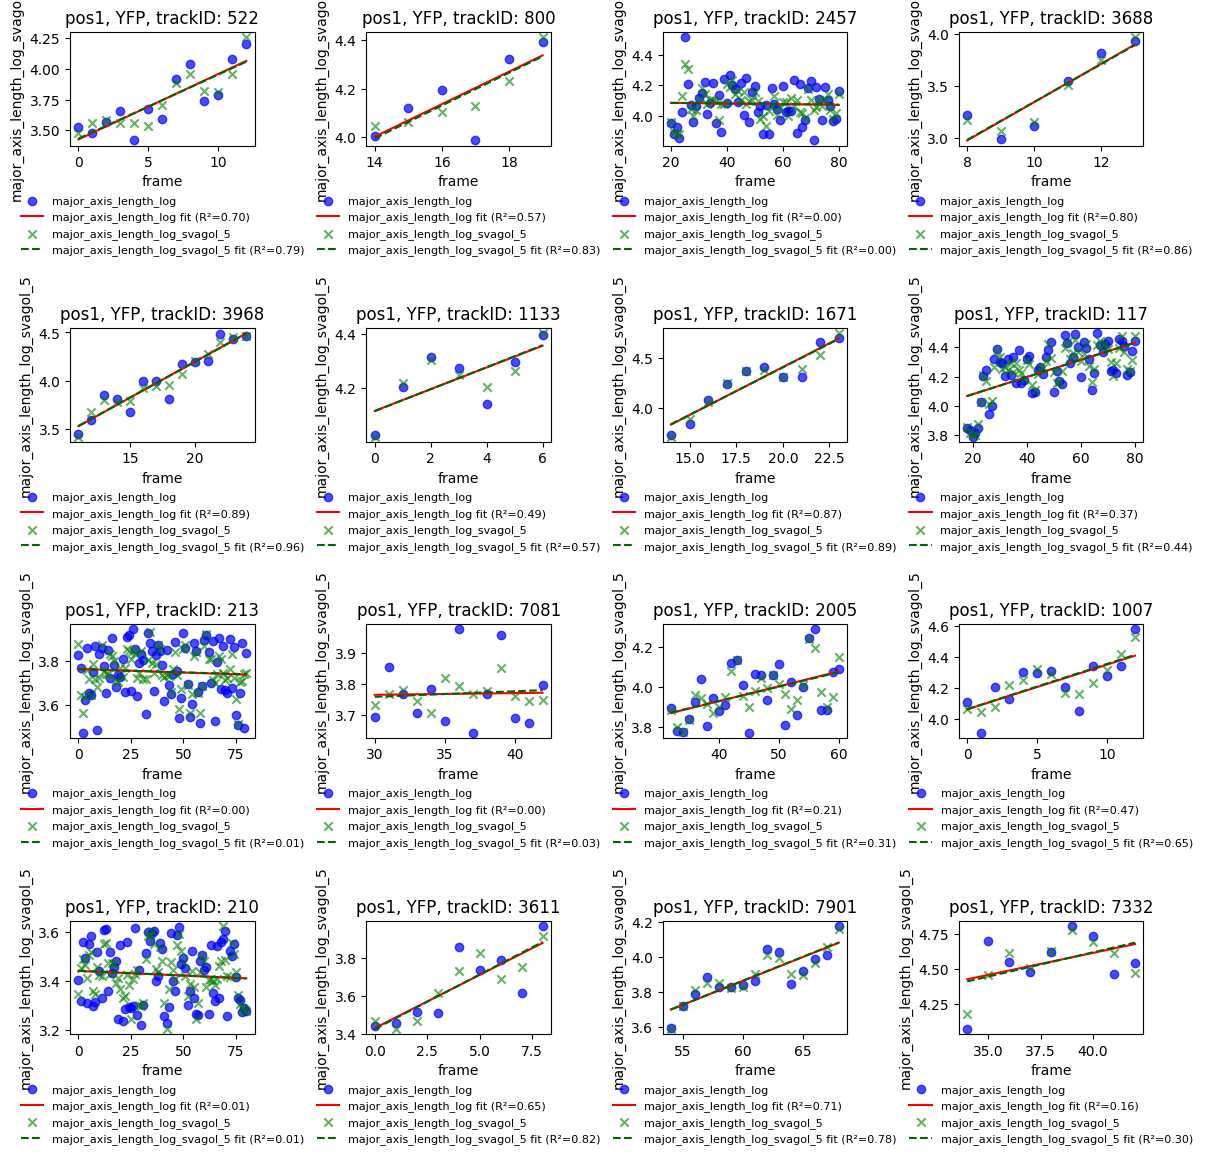

LINEAR at 5: simple convolution (linear)


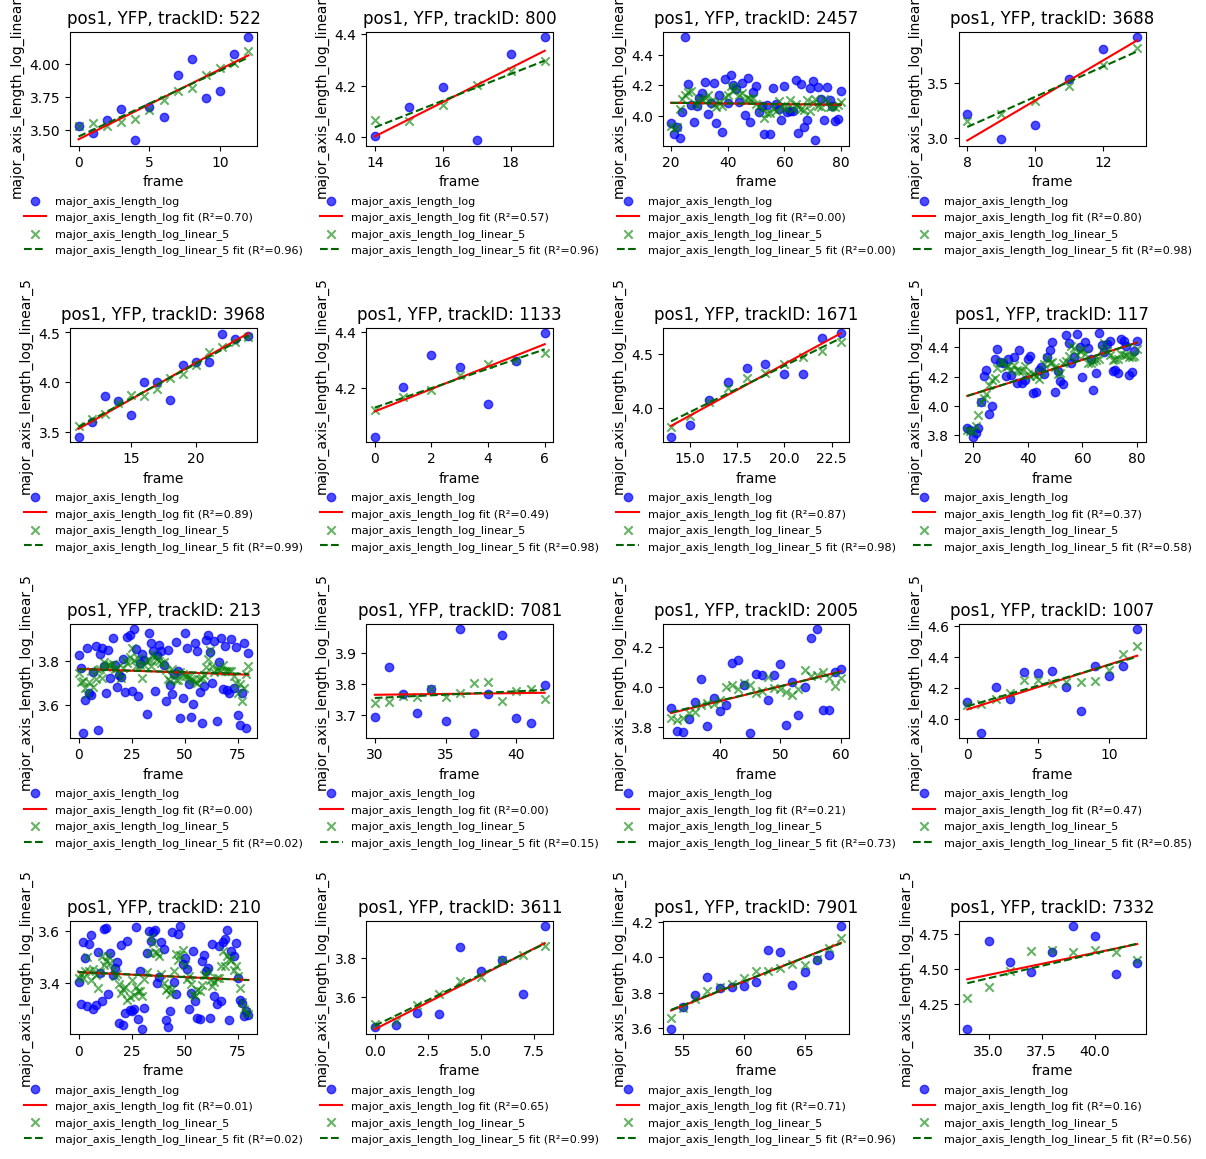

LOESS at 5: vectorized loess with 2nd order


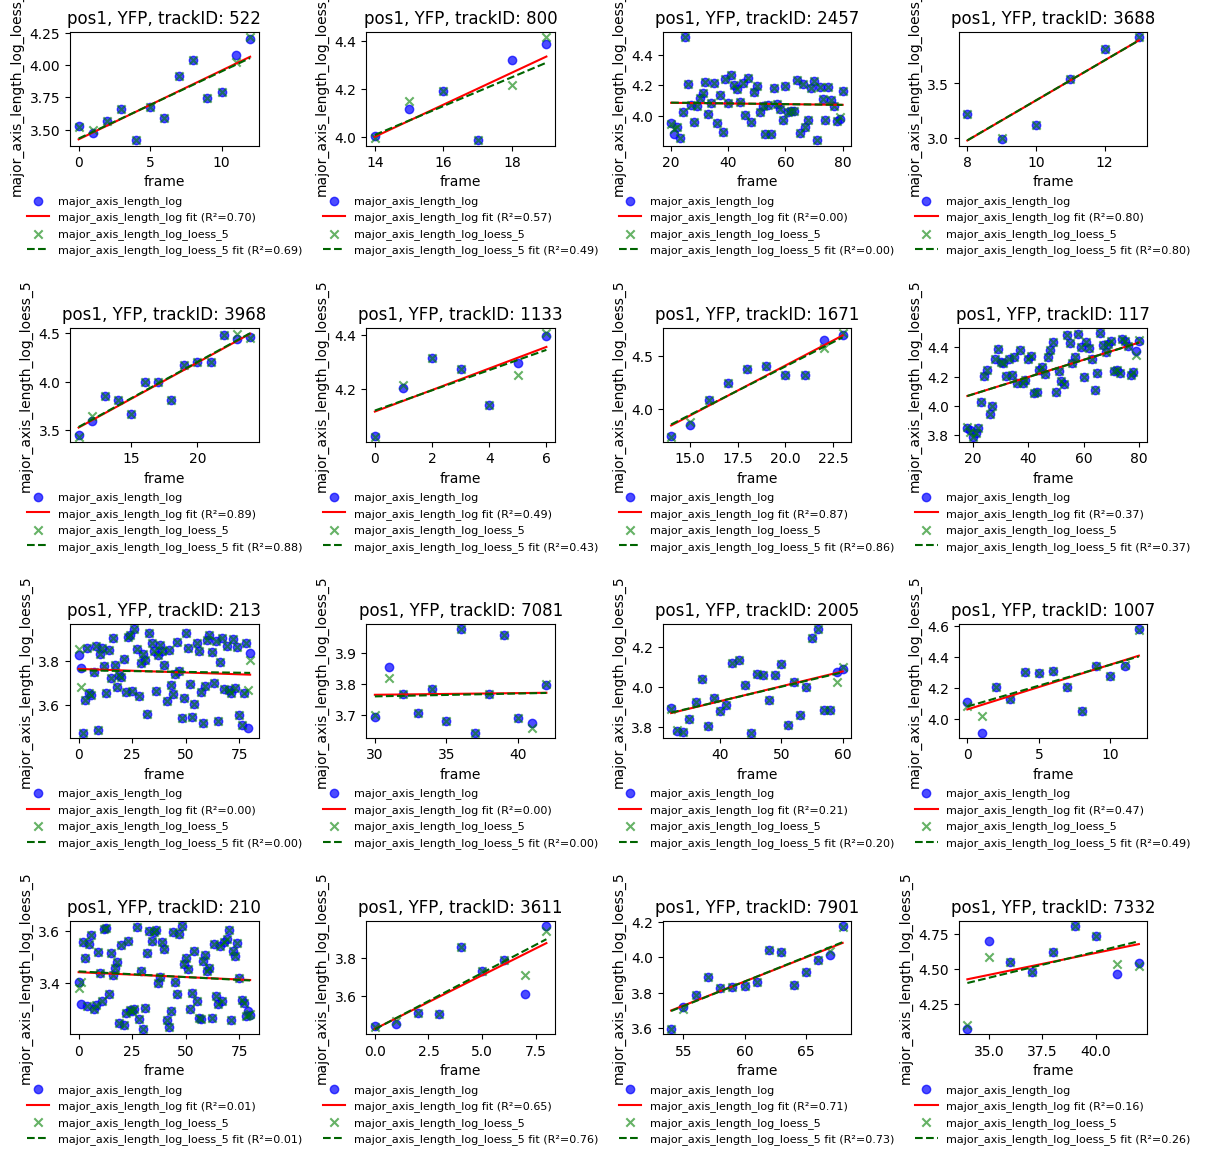

LOWESS at 5: vectorized lowess with 1st order


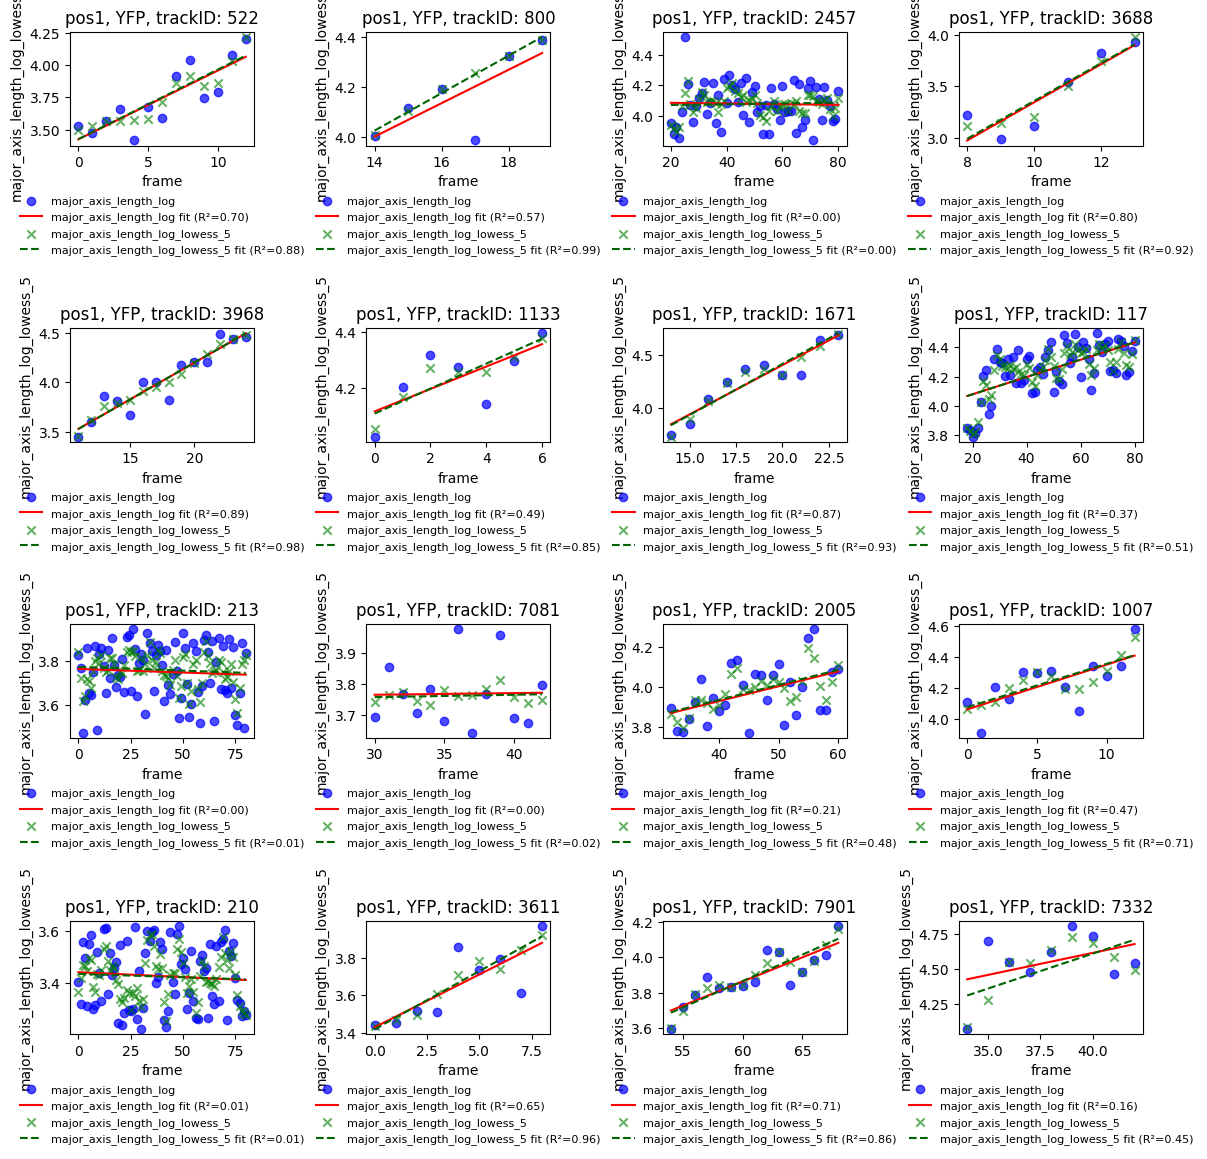

SVAGOL at 7: 2nd order poly


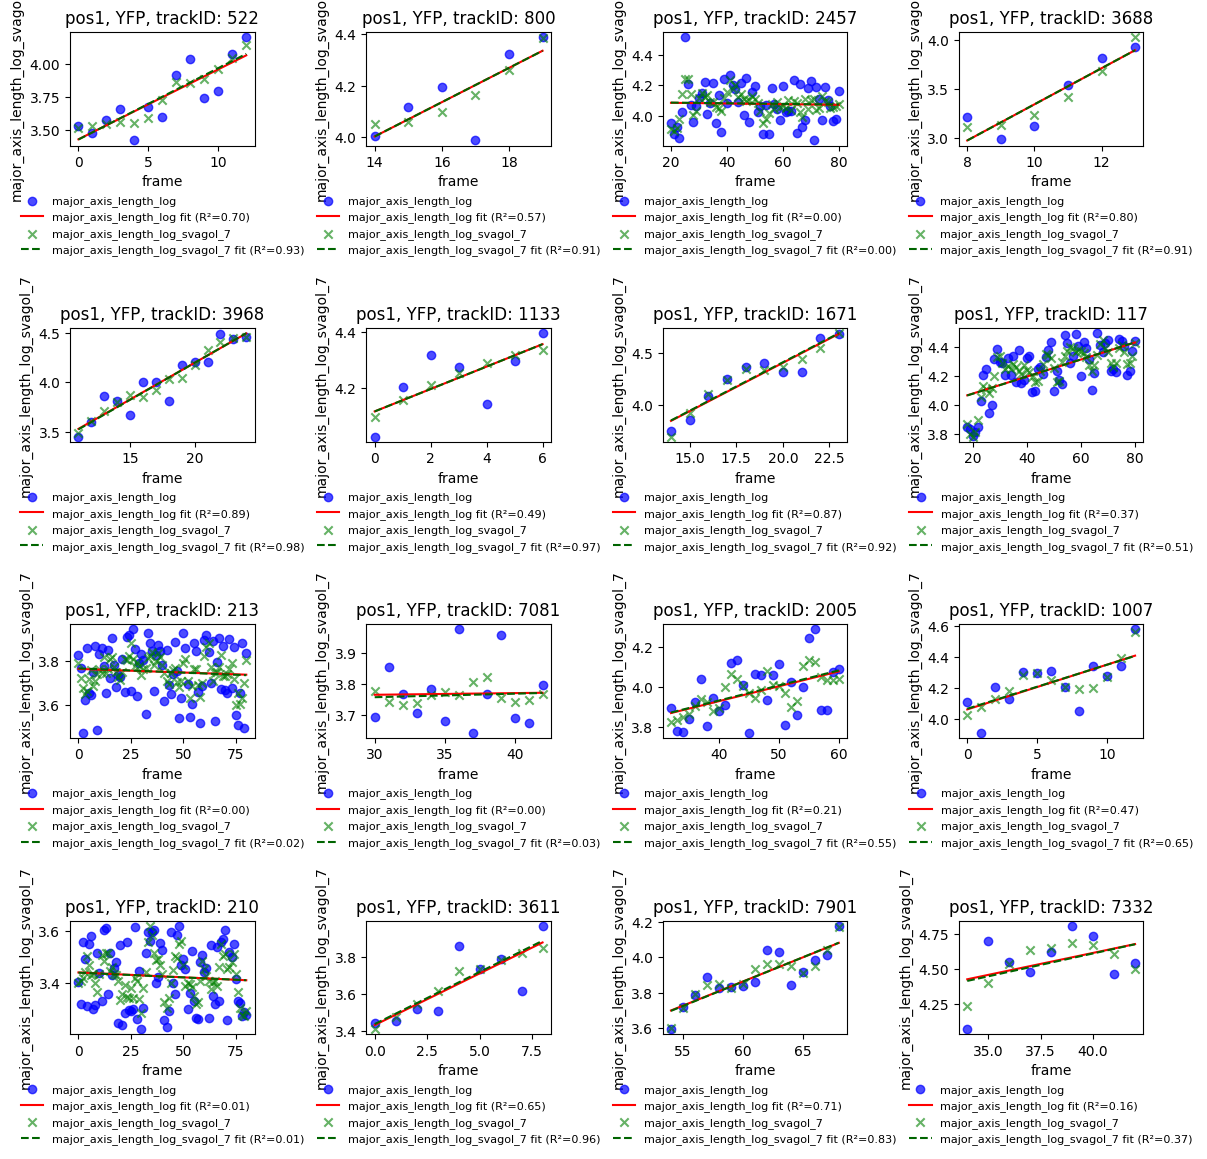

LINEAR at 7: simple convolution (linear)


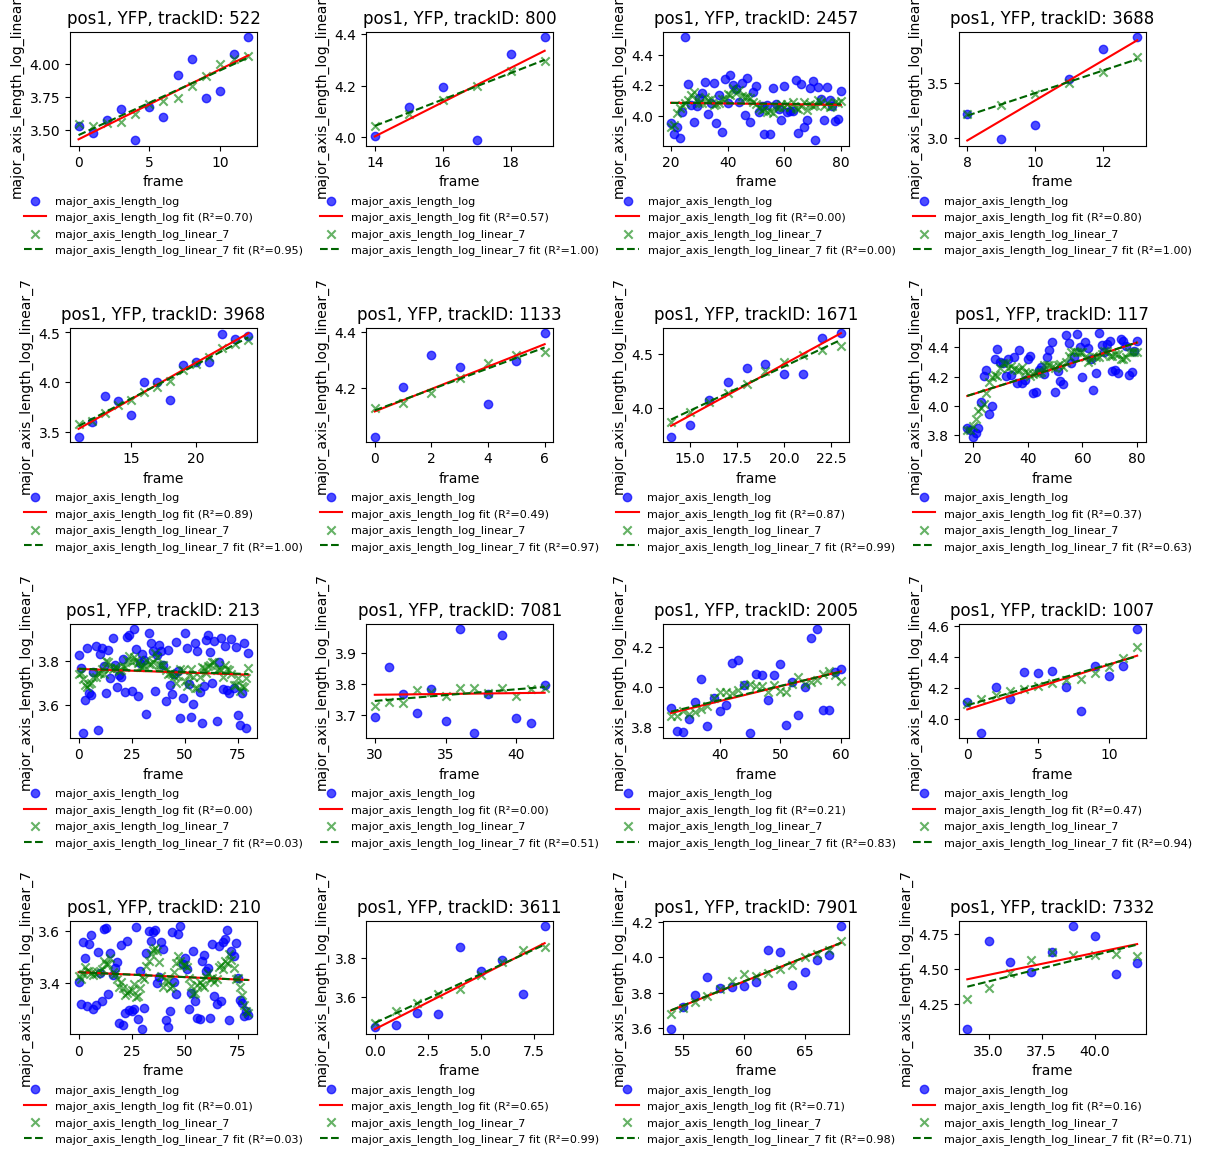

LOESS at 7: vectorized loess with 2nd order


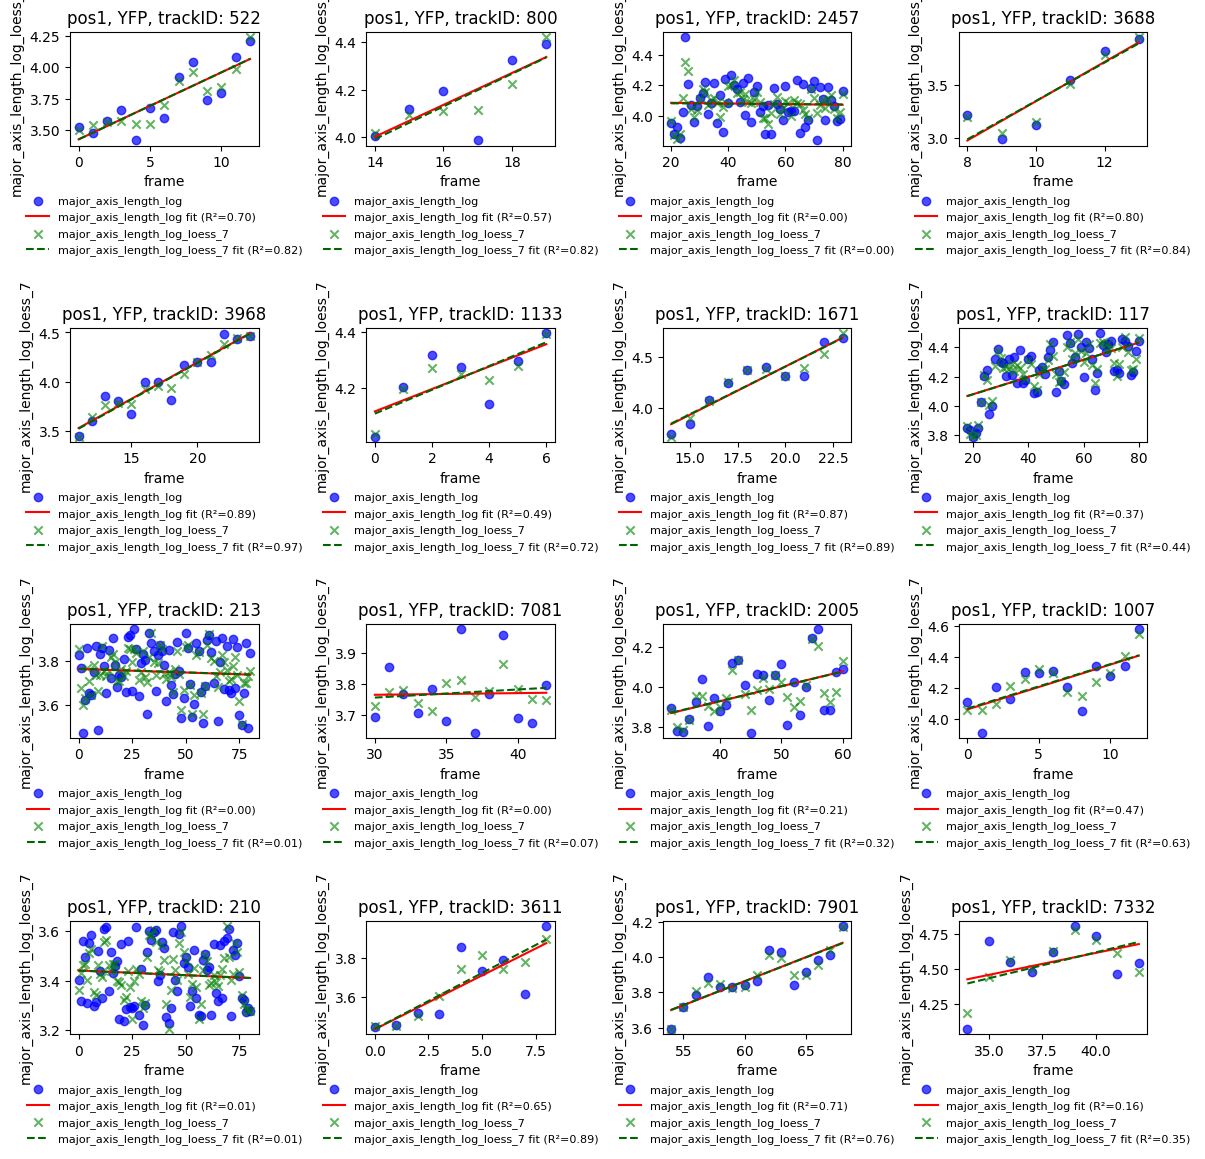

LOWESS at 7: vectorized lowess with 1st order


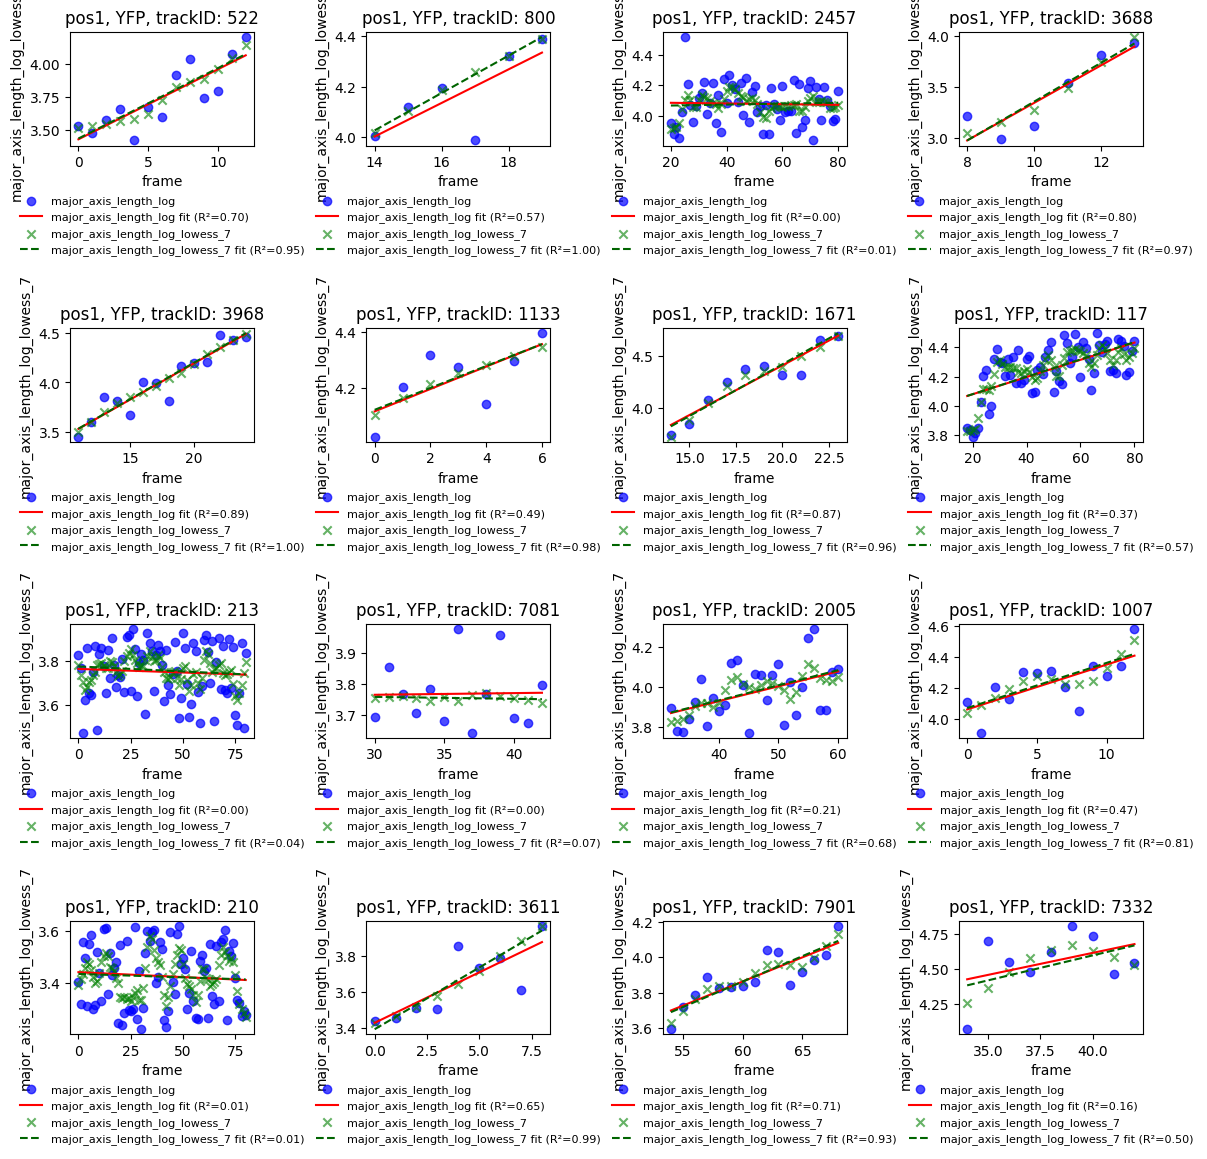

SVAGOL at 9: 2nd order poly


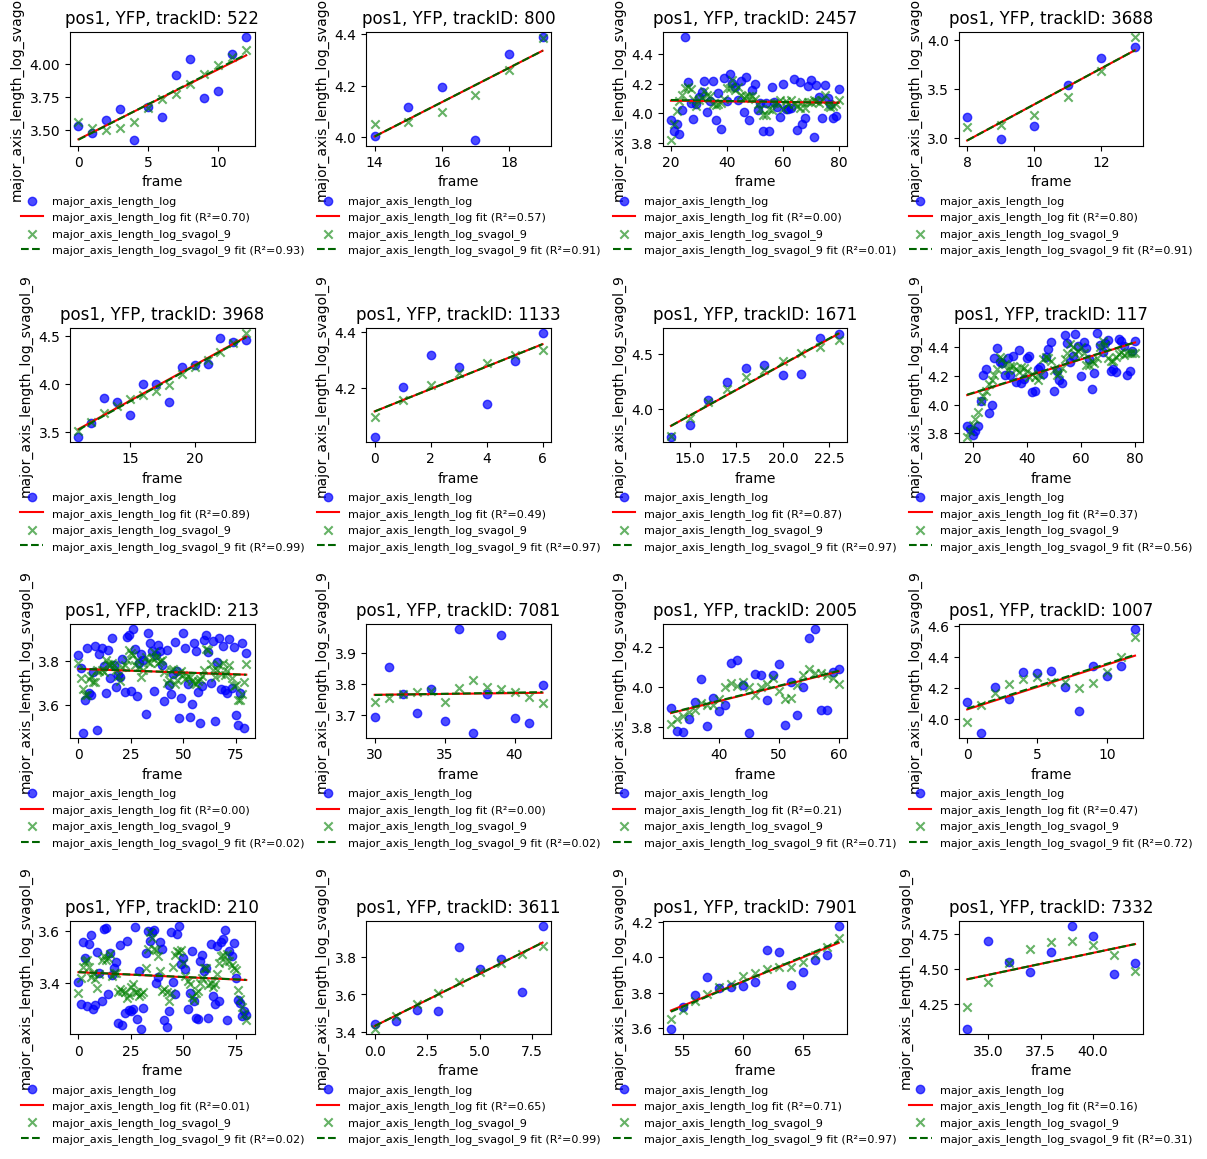

LINEAR at 9: simple convolution (linear)


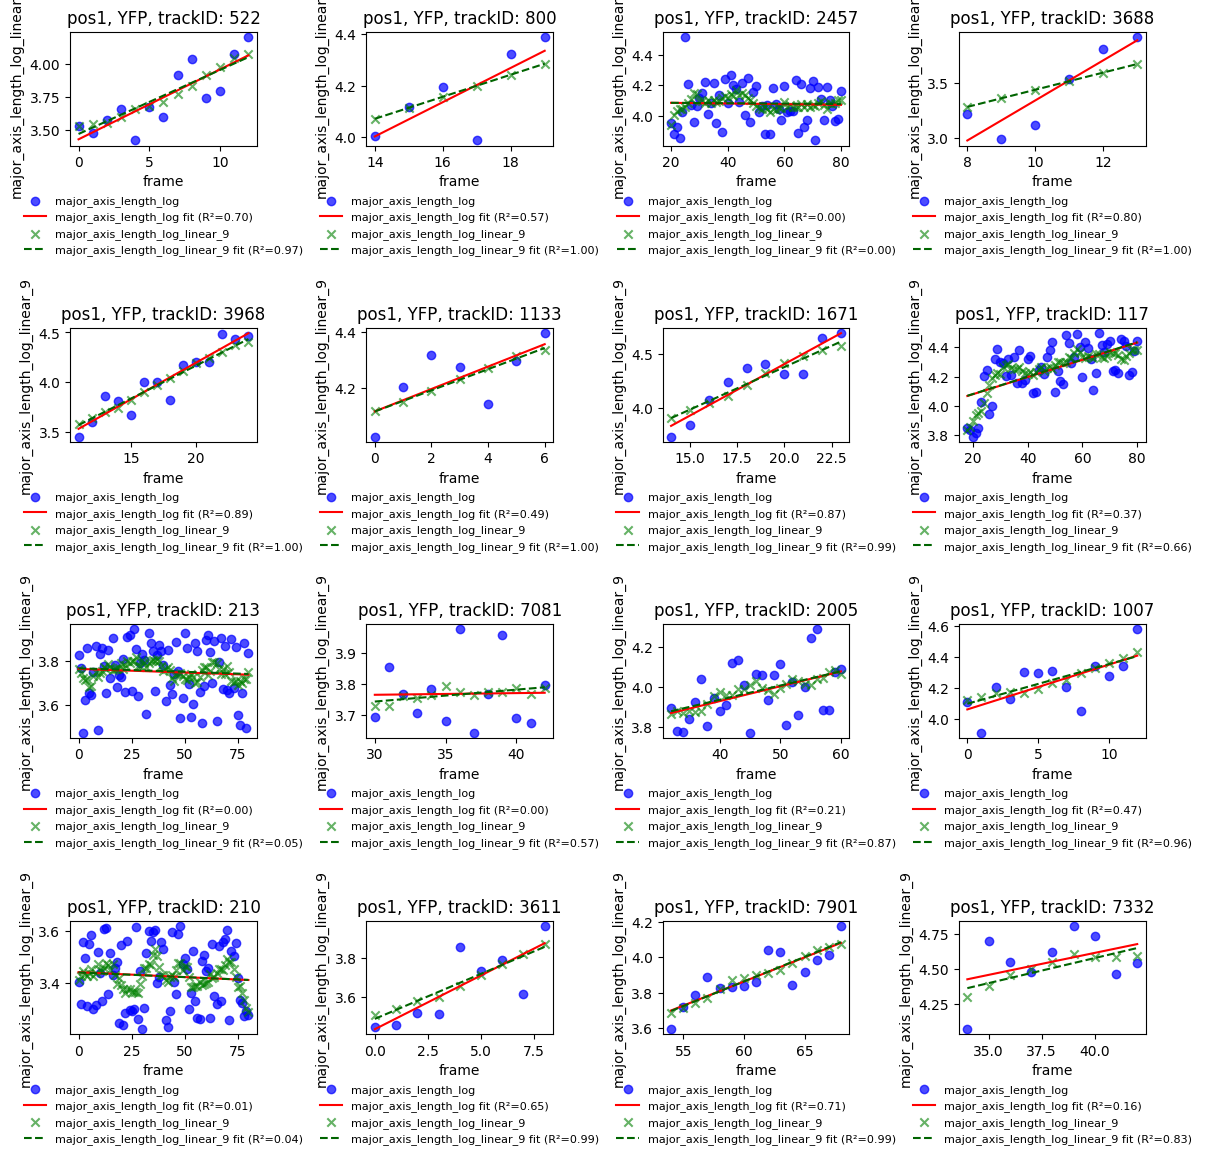

LOESS at 9: vectorized loess with 2nd order


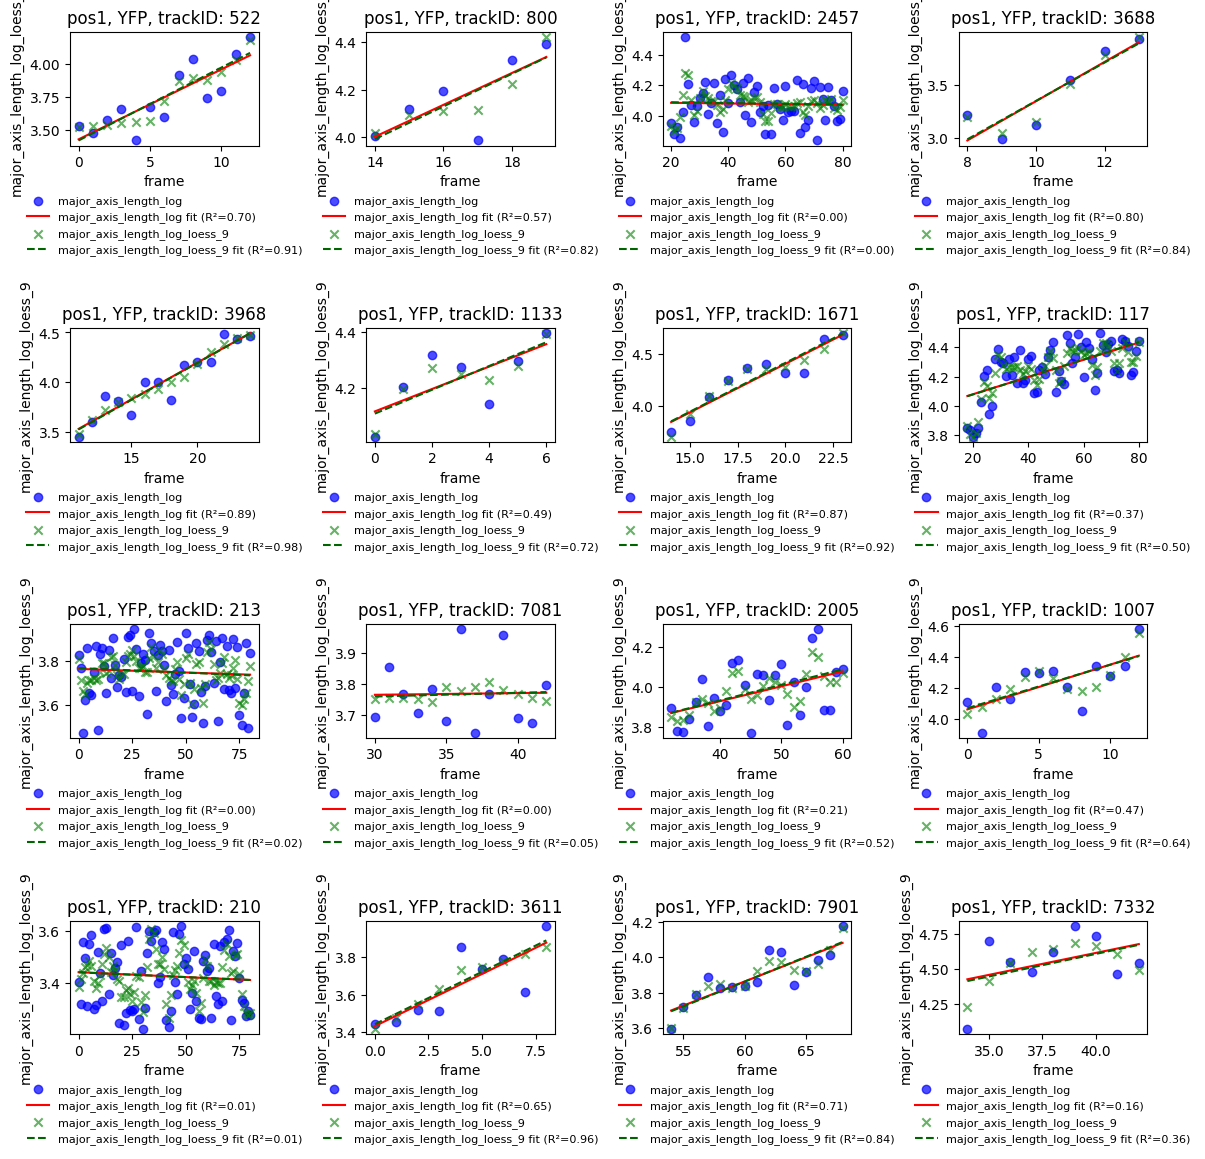

LOWESS at 9: vectorized lowess with 1st order


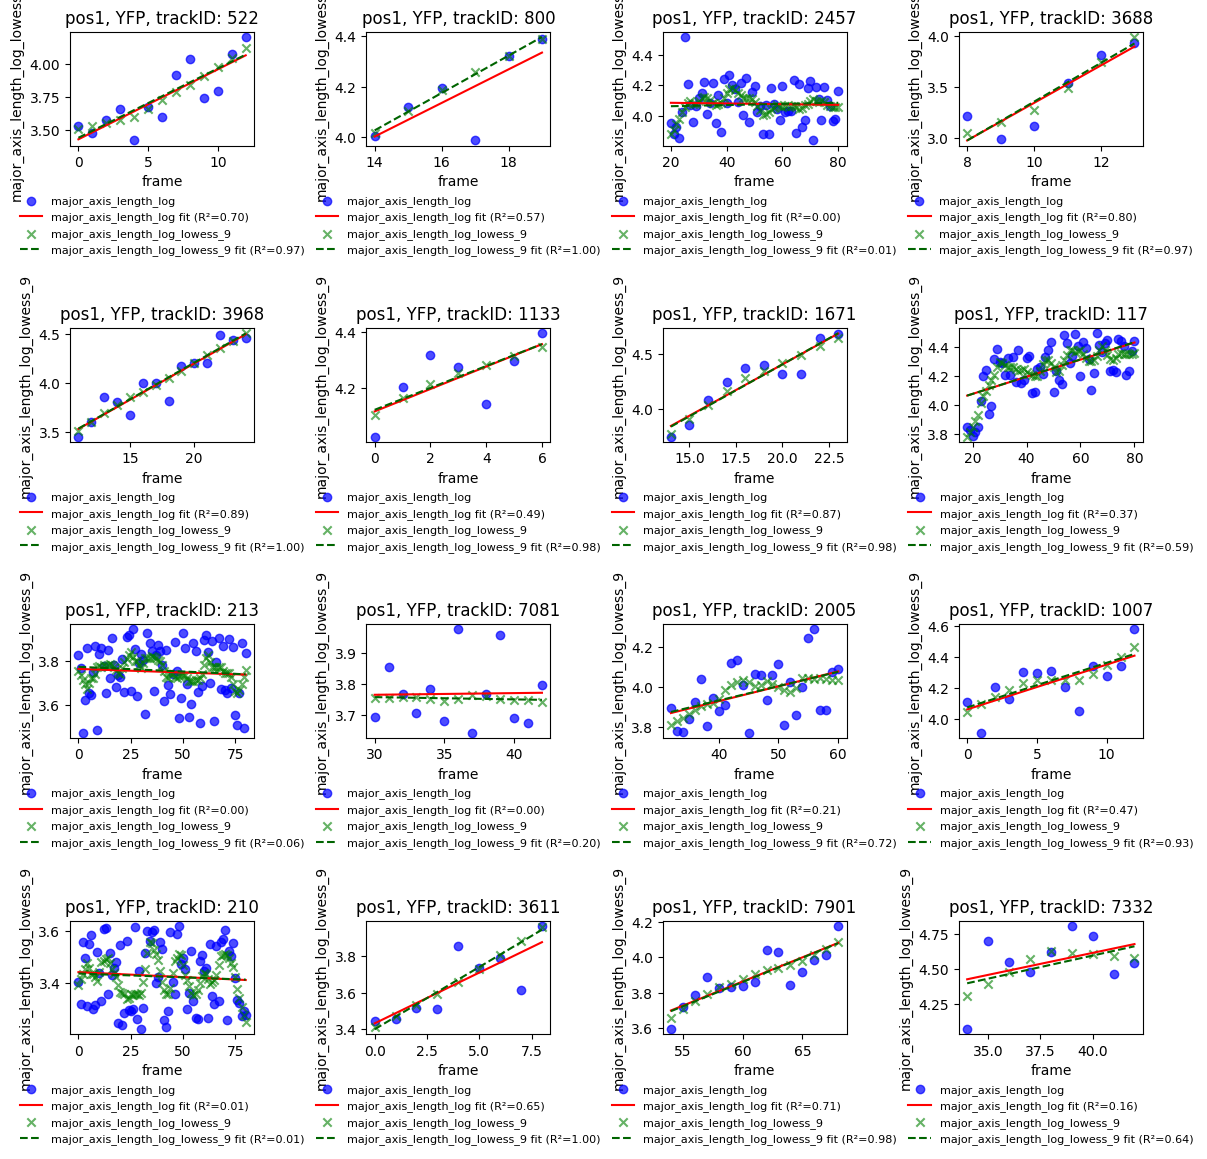

In [ ]:
POS = "pos1"  #positions to plot data from
N = 16 # n examples to plot from each position / channel
COLOR_CHANNELS = "YFP" #channels to plot data from

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        name = m["name"]
        desc = m["desciption"]
        print(f"{name} at smoothing window {w}: {desc}")
        overlay_col_name = log_col_name + m["postfix"] + f"_{w}"
        exp.plot_qc(value_column=log_col_name,frame_column="frame", n_samples=N, overlay_column=overlay_col_name, free_overlay_axes= False, positions=POS, color_channels= COLOR_CHANNELS)


# Calculate growth rates with smoothed data

In [8]:
growth_rate_integration = 5  #what integration period do we use when calculating the growth rate?

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        method_column = log_col_name + m["postfix"] + f"_{w}"
        growth_rate_column = "growth_rate" + m["postfix"] + f"_{w}"
        exp.calculate_growth_rate(growth_rate_integration,"trackID", method_column,growth_rate_column=growth_rate_column)
    

Calculate growth_rate_svagol_5 for trackID measured with major_axis_length_log_svagol_5 over an integration window of 5
Calculate growth_rate_linear_5 for trackID measured with major_axis_length_log_linear_5 over an integration window of 5
Calculate growth_rate_loess_5 for trackID measured with major_axis_length_log_loess_5 over an integration window of 5
Calculate growth_rate_lowess_5 for trackID measured with major_axis_length_log_lowess_5 over an integration window of 5
Calculate growth_rate_svagol_7 for trackID measured with major_axis_length_log_svagol_7 over an integration window of 5
Calculate growth_rate_linear_7 for trackID measured with major_axis_length_log_linear_7 over an integration window of 5
Calculate growth_rate_loess_7 for trackID measured with major_axis_length_log_loess_7 over an integration window of 5
Calculate growth_rate_lowess_7 for trackID measured with major_axis_length_log_lowess_7 over an integration window of 5
Calculate growth_rate_svagol_9 for trackID m

# create rate plots for a selected position / color channel

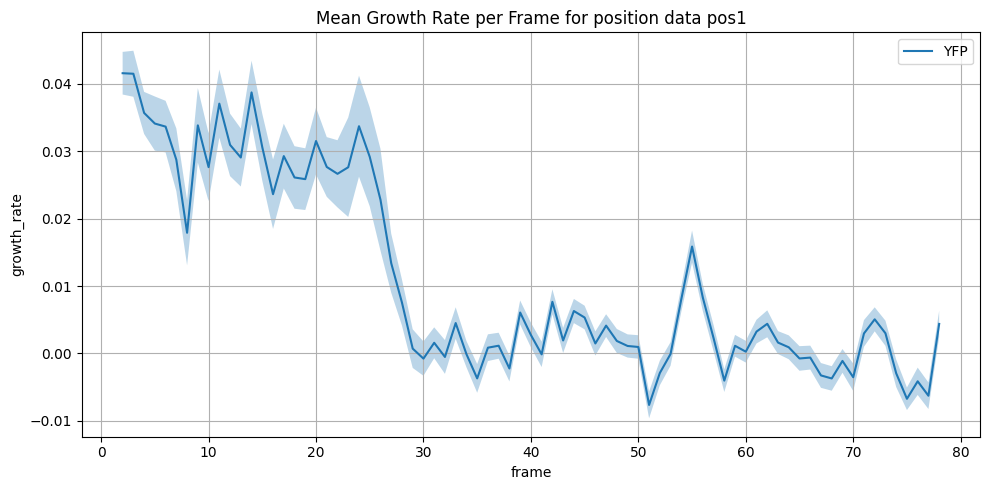

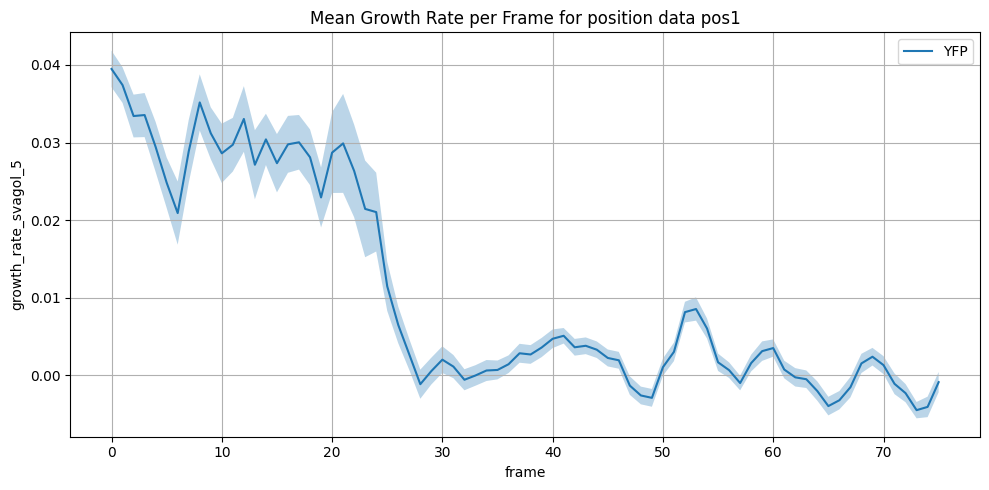

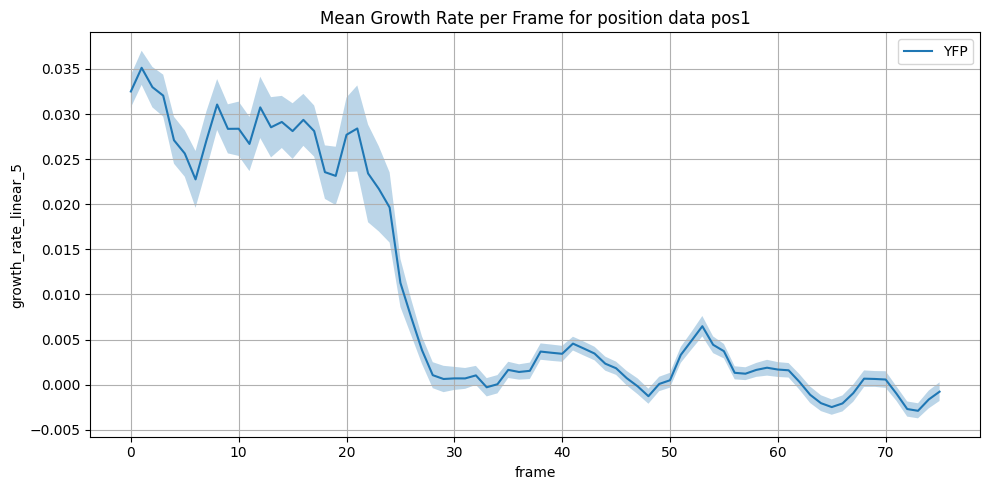

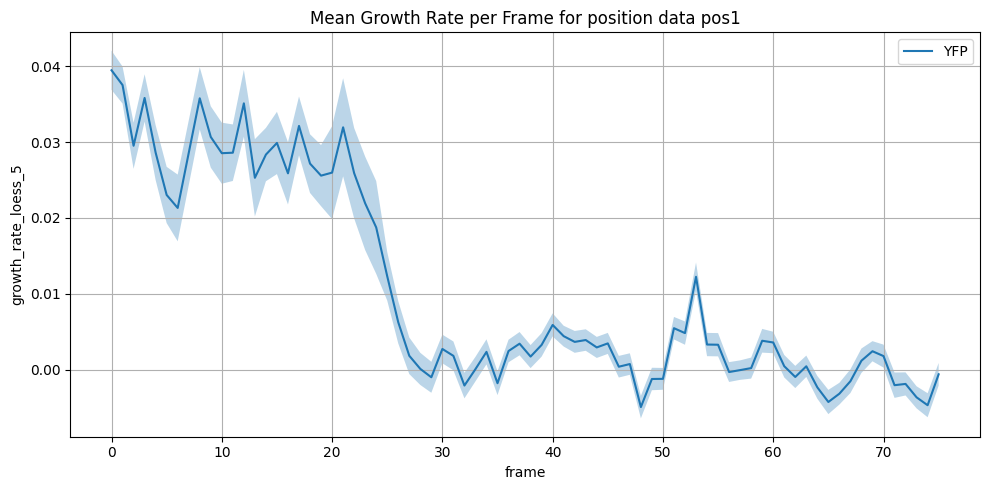

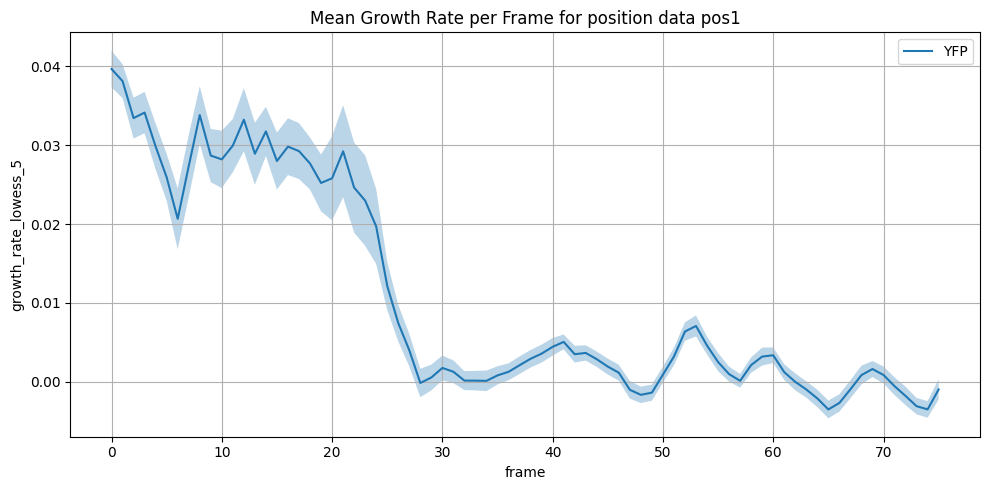

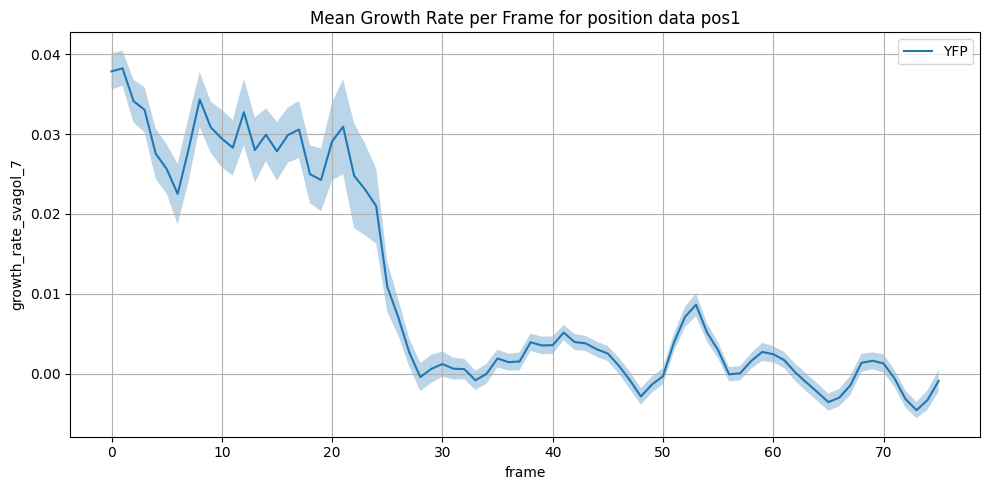

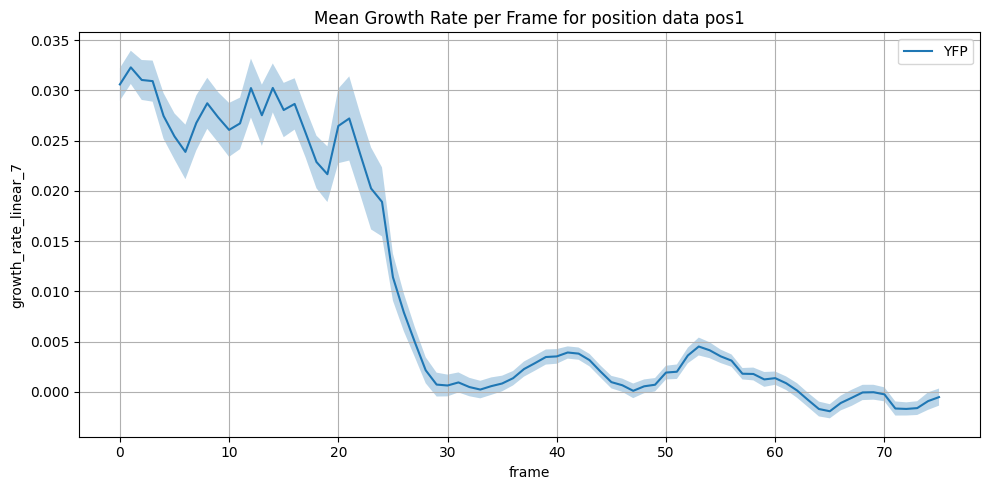

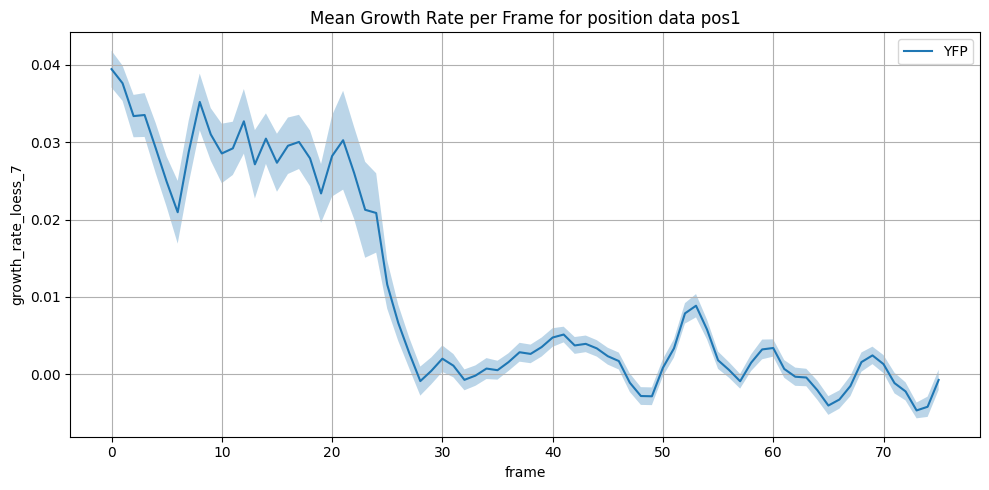

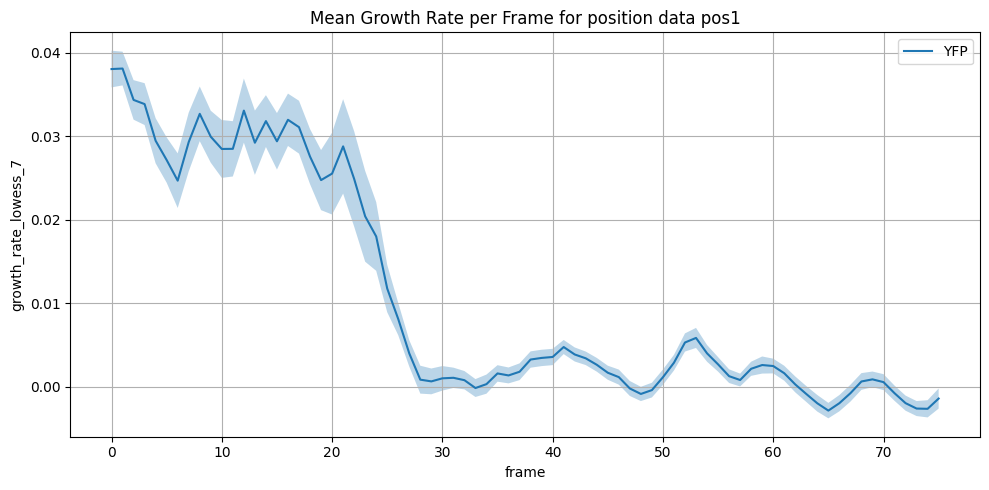

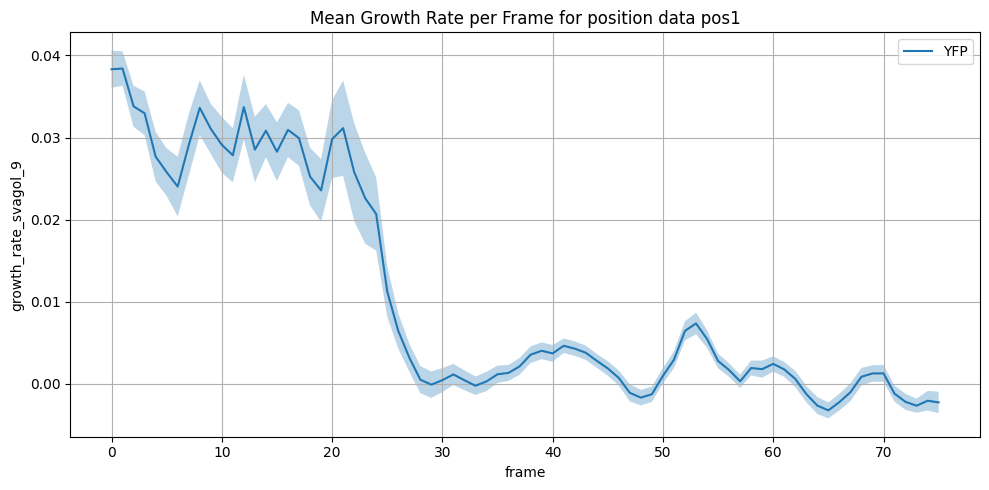

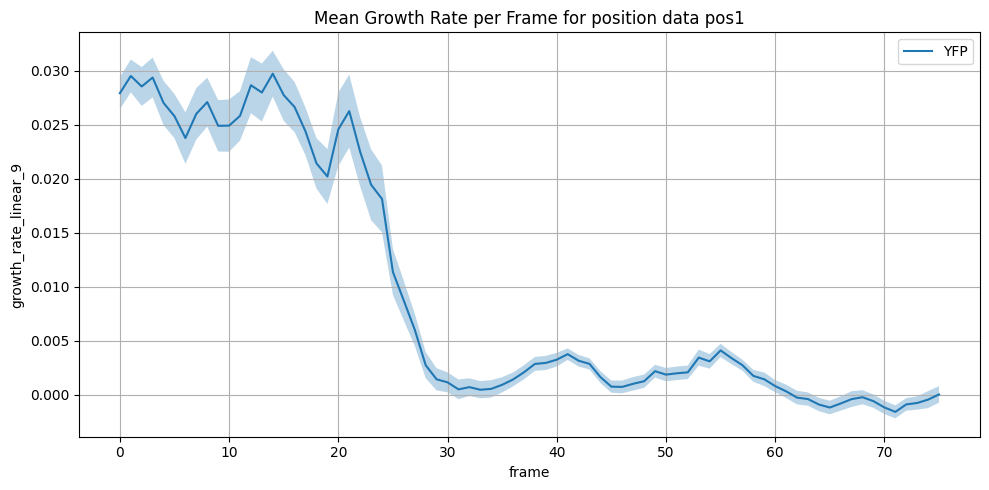

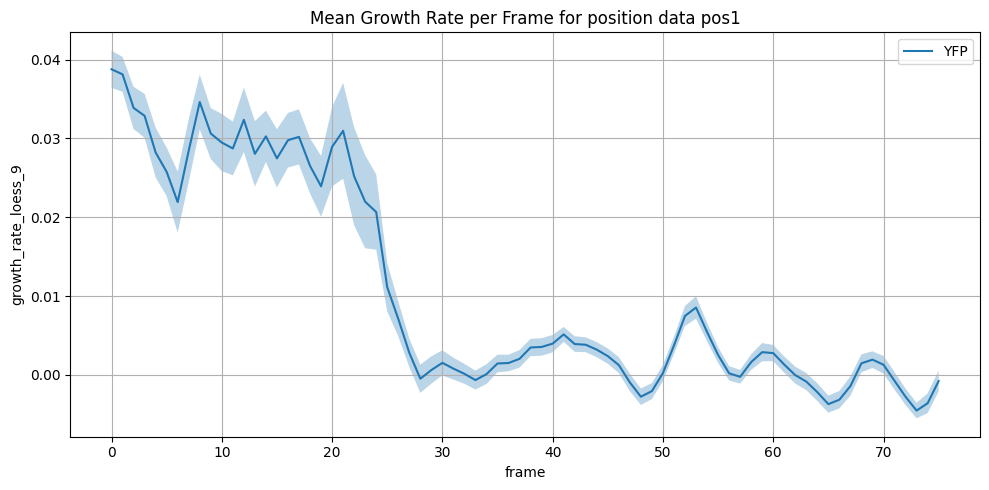

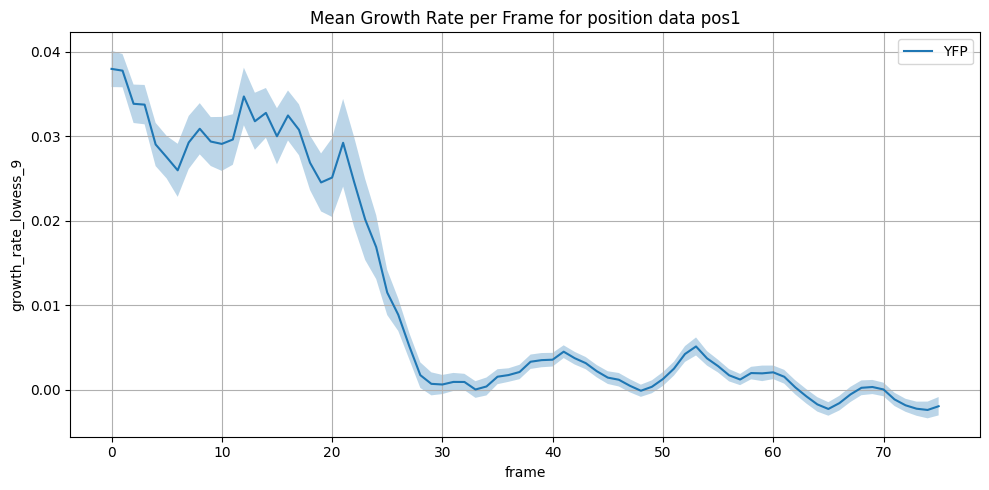

In [11]:
#Note, only works if you have loaded metadata template with groups

POSITIONS = ["pos1"]
COLOR_CHANNELS = ["YFP"]

exp.plot_rates(rate_column="growth_rate", positions= POSITIONS, color_channels = COLOR_CHANNELS)

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        growth_rate_column = "growth_rate" + m["postfix"] + f"_{w}"
        exp.plot_rates(rate_column=growth_rate_column, positions= POSITIONS, color_channels = COLOR_CHANNELS)

# create rate plots of groups based on smoothed data

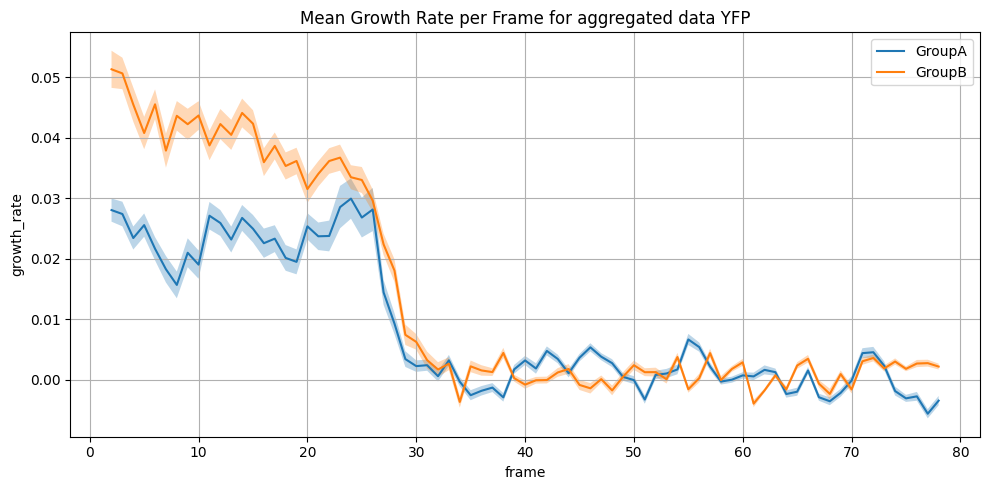

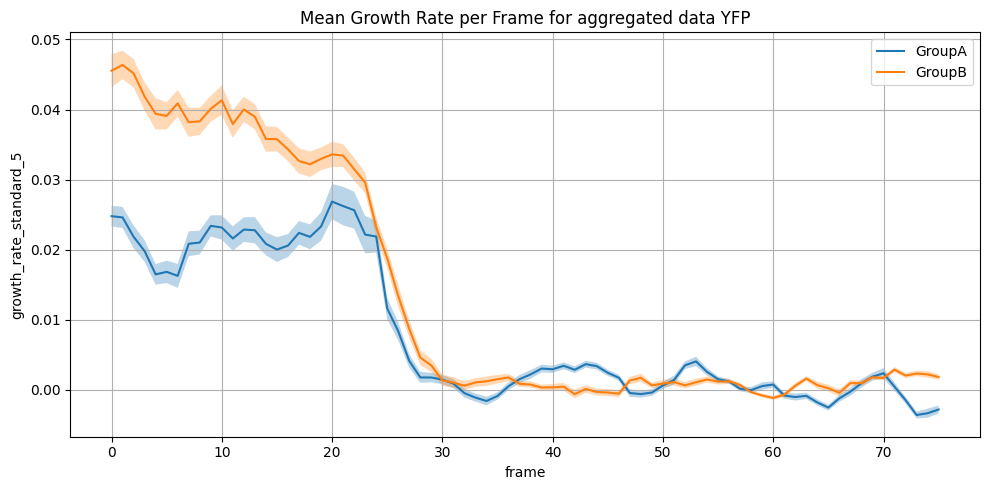

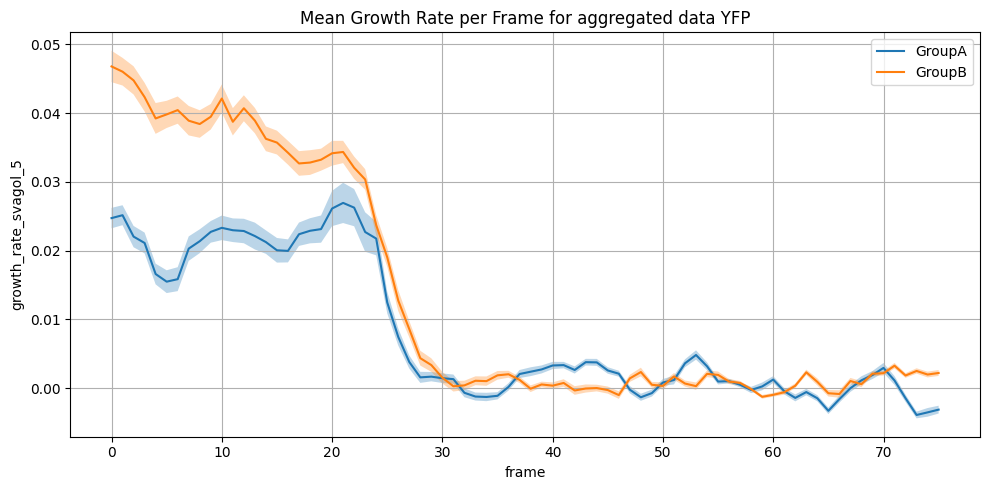

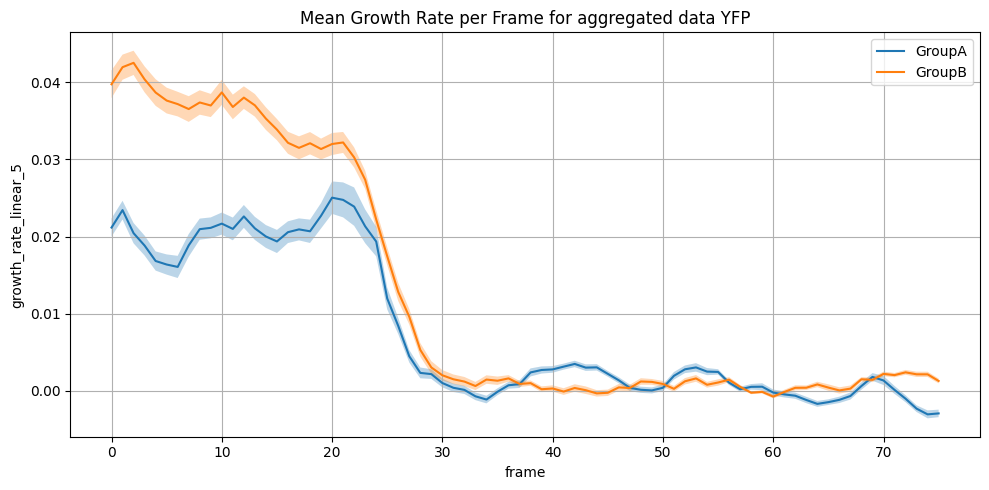

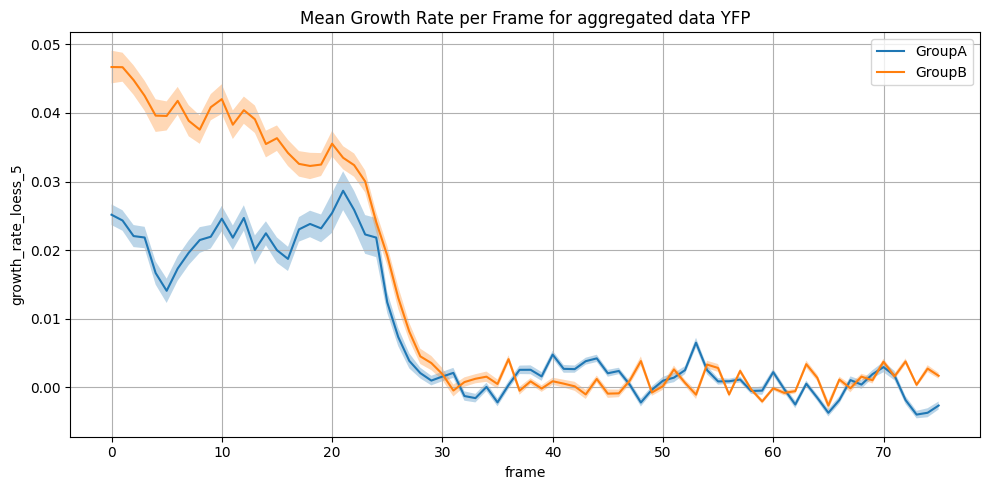

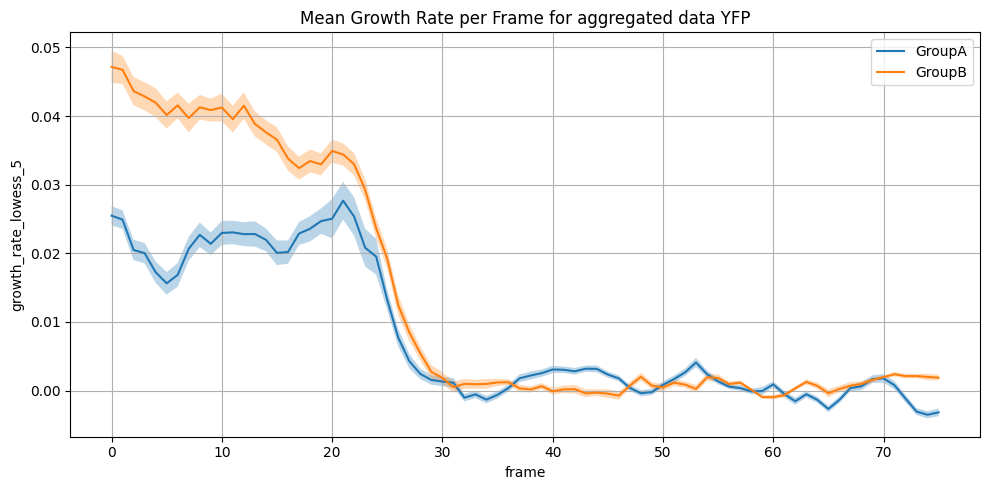

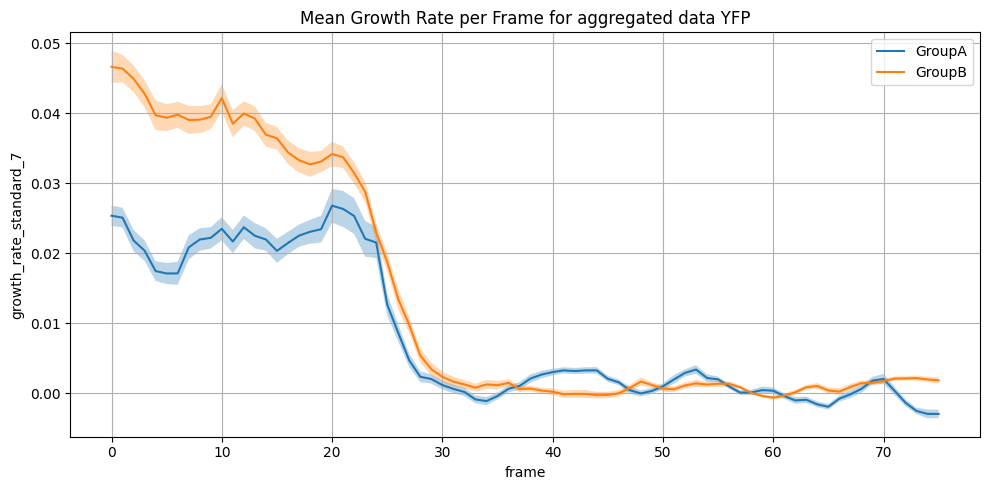

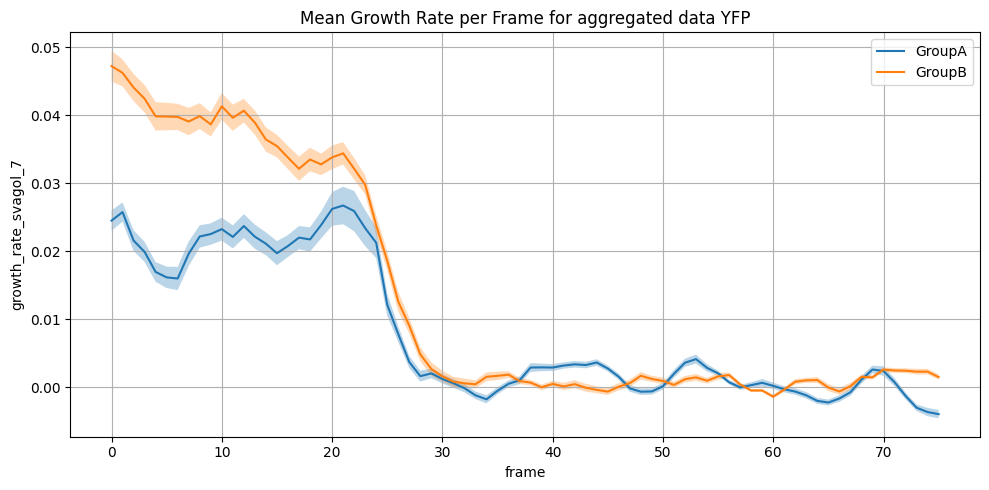

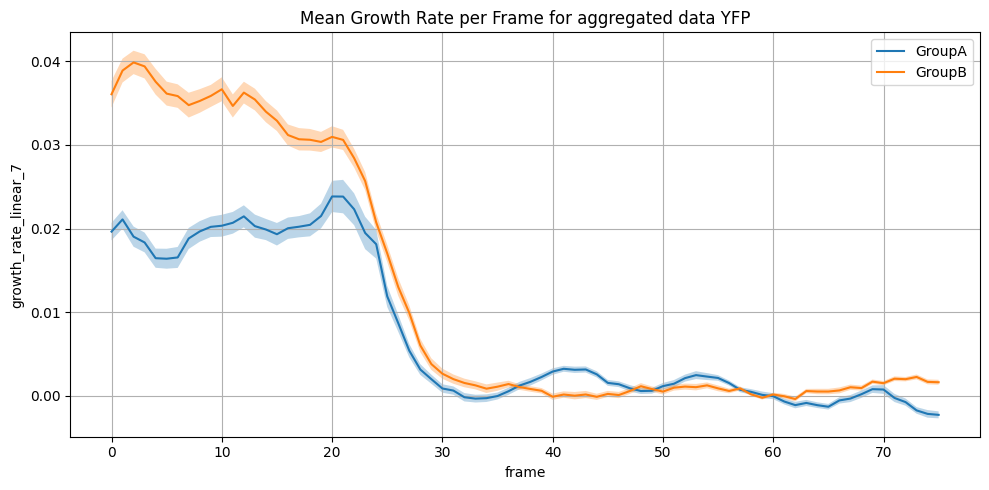

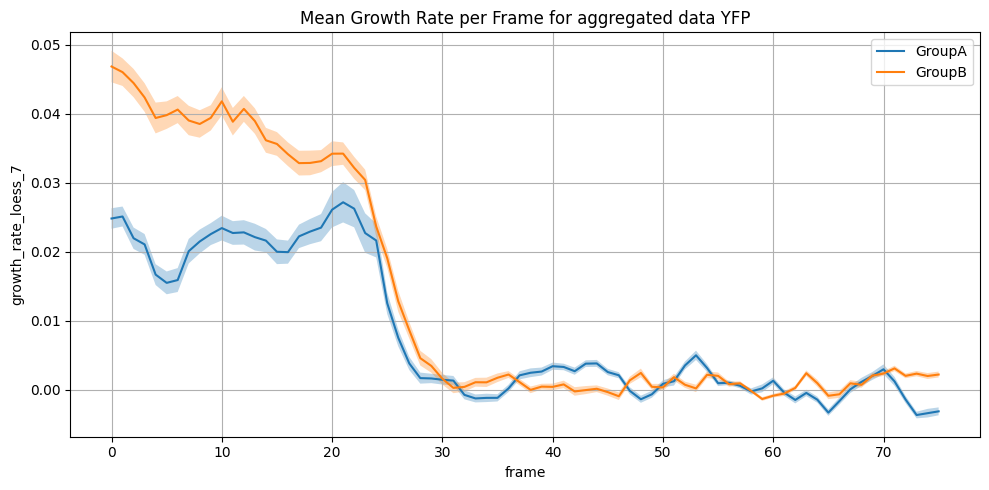

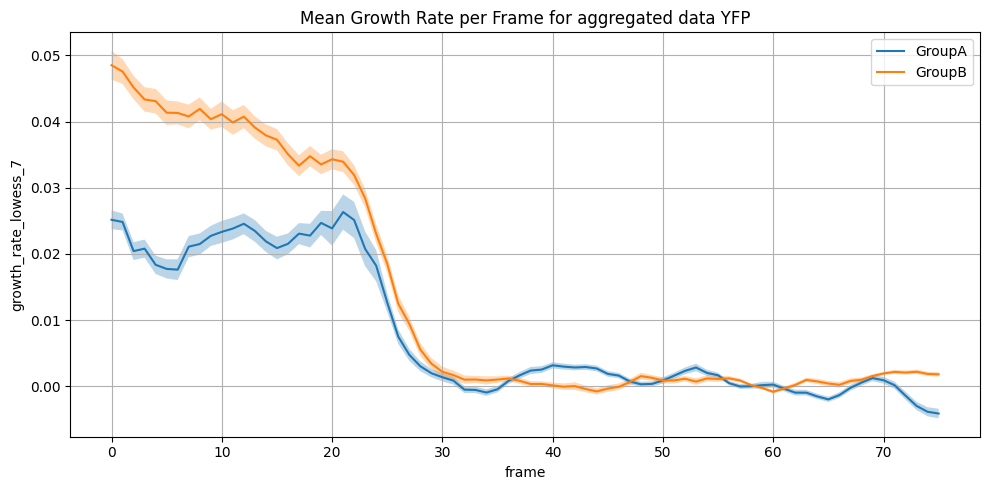

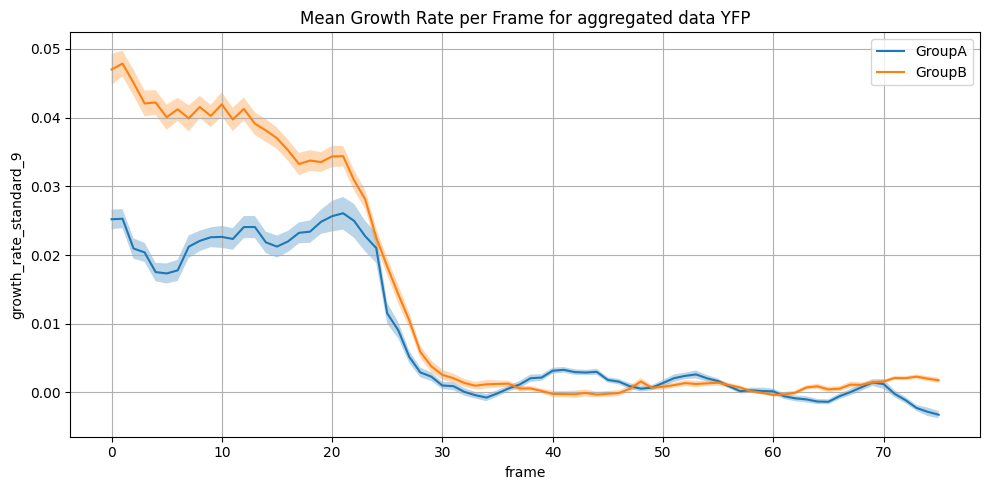

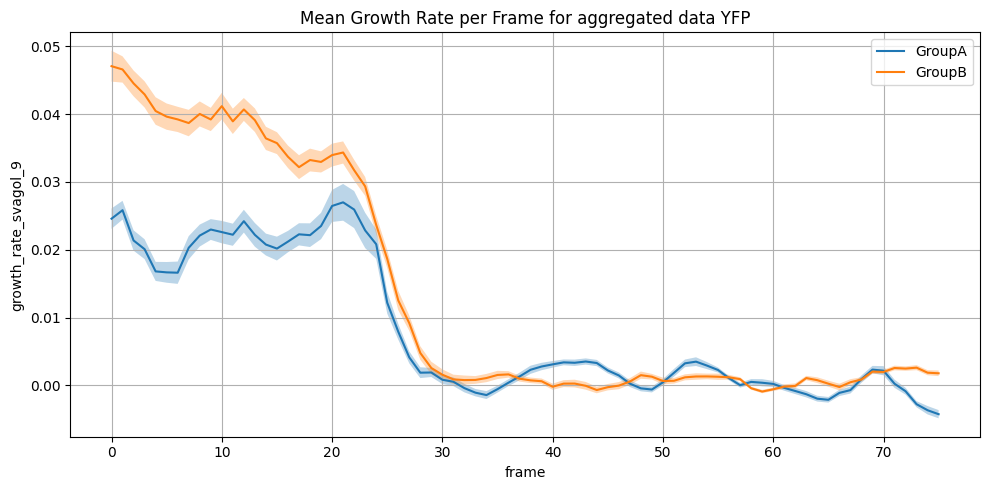

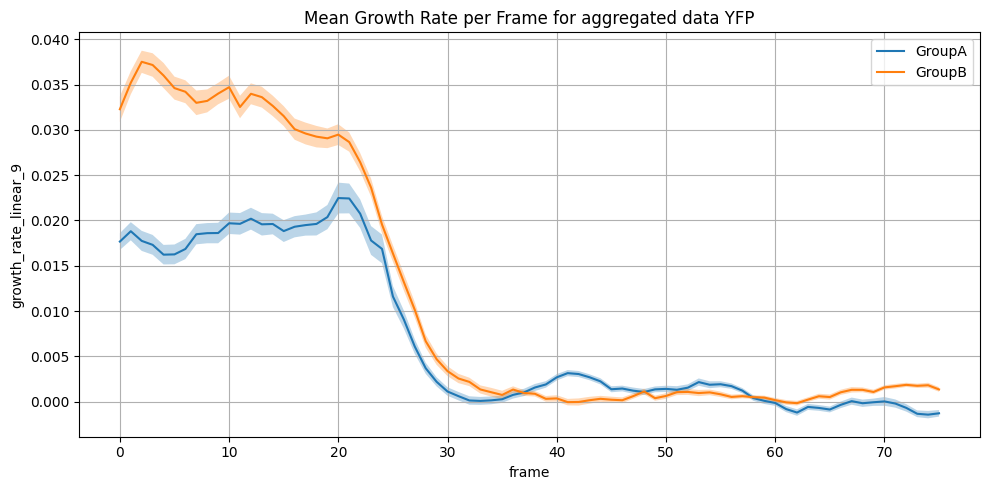

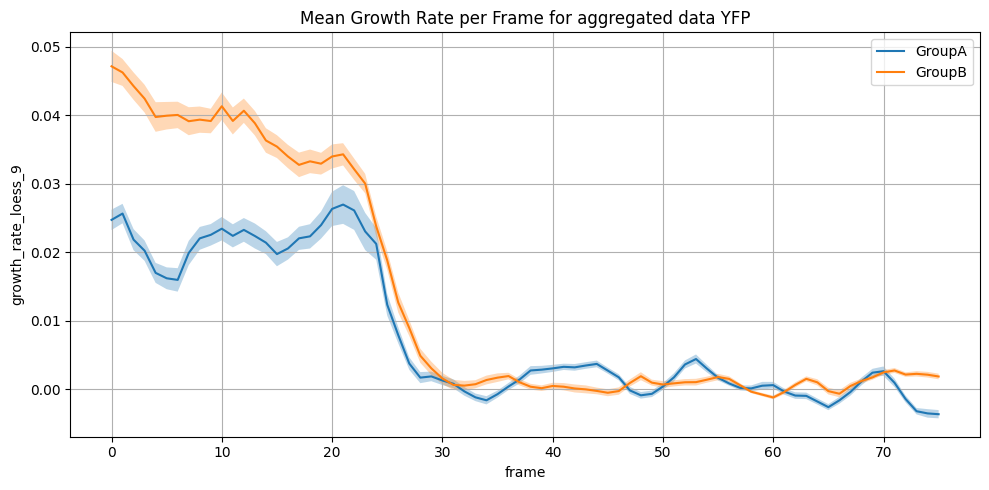

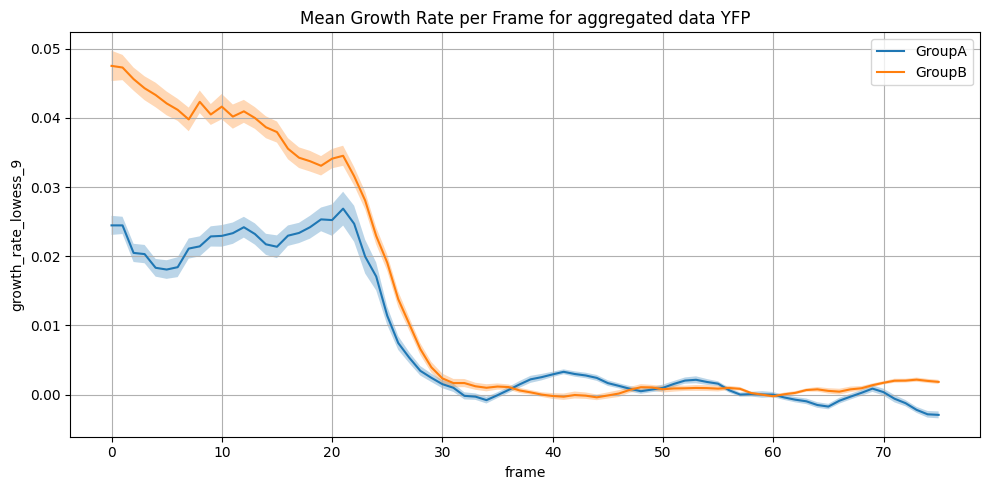

In [ ]:
#Note, only works if you have loaded metadata template with groups

exp.plot_rates(rate_column="growth_rate",group_by="group", color_channels = ["YFP"], flip_grouping=True)

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        growth_rate_column = "growth_rate" + m["postfix"] + f"_{w}"
        exp.plot_rates(rate_column=growth_rate_column,group_by="group", color_channels = ["YFP"], flip_grouping=True)
